In [27]:
# === 1. Import des bibliothèques ===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid")


In [28]:
# === 2. Chargement automatique des annotations (train, valid, test) ===
root = Path(r"C:\Machine Learning\projet\projet-machine-learning\dataset\labels")
label_files = list(root.rglob("*.txt"))

rows = []
for f in label_files:
    split = f.parent.name  # train / valid / test
    with open(f, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = parts
                rows.append({
                    "split": split,
                    "file": f.stem,
                    "class_id": int(cls),
                    "x_center": float(xc),
                    "y_center": float(yc),
                    "width": float(w),
                    "height": float(h)
                })

df = pd.DataFrame(rows)
print("Dataset chargé avec succès !")
print(f"Nombre total d’annotations : {len(df)}")
print(f"Nombre de fichiers (.txt) trouvés : {len(label_files)}")
print(f"Répartition par split :\n{df['split'].value_counts()}")
df.head(10)


Dataset chargé avec succès !
Nombre total d’annotations : 6354
Nombre de fichiers (.txt) trouvés : 1980
Répartition par split :
split
train    4424
valid    1312
test      618
Name: count, dtype: int64


,split,file,class_id,x_center,y_center,width,height
0,test,gss1009_jpg.rf.011f90d6db5a951391df1e9048781547,1,0.110156,0.557407,0.024479,0.070370
1,test,gss1009_jpg.rf.011f90d6db5a951391df1e9048781547,1,0.445573,0.407870,0.017188,0.060185
2,test,gss1010_jpg.rf.63dcdae3f51c0318c1811ae94f5f2869,5,0.230990,0.489352,0.021354,0.060185
3,test,gss1010_jpg.rf.63dcdae3f51c0318c1811ae94f5f2869,5,0.570312,0.416204,0.014583,0.063889
4,test,gss1010_jpg.rf.63dcdae3f51c0318c1811ae94f5f2869,4,0.042708,0.422685,0.017708,0.036111
5,test,gss1027_jpg.rf.61b7131736a5513c1085a8c294e02473,1,0.096615,0.453704,0.020313,0.059259
6,test,gss1027_jpg.rf.61b7131736a5513c1085a8c294e02473,4,0.156510,0.381019,0.011979,0.039815
7,test,gss1027_jpg.rf.61b7131736a5513c1085a8c294e02473,5,0.201302,0.393056,0.017188,0.050926
8,test,gss1027_jpg.rf.61b7131736a5513c1085a8c294e02473,1,0.555469,0.472685,0.019271,0.056481
9,test,gss1027_jpg.rf.61b7131736a5513c1085a8c294e02473,5,0.673958,0.395370,0.015625,0.062963


In [30]:
# === 2 bis. Ajout des noms de classes ===
classes = {
    0: "Running",
    1: "Walking",
    2: "Laying_down",
    3: "Not_defined",
    4: "Seated",
    5: "Stands"
}

df["class_name"] = df["class_id"].map(classes)

print("✅ Colonne 'class_name' ajoutée avec succès !")
print(df[["class_id", "class_name"]].drop_duplicates().sort_values("class_id"))


✅ Colonne 'class_name' ajoutée avec succès !
     class_id   class_name
167         0      Running
0           1      Walking
22          2  Laying_down
58          3  Not_defined
4           4       Seated
2           5       Stands


C:\Users\benwa\AppData\Local\Temp\ipykernel_18044\2211994226.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_counts.index, y=split_counts.values, palette="crest")


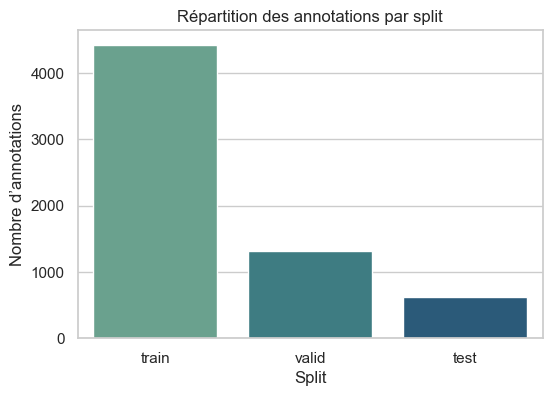

📂 Répartition des annotations par split :
split
train    4424
valid    1312
test      618
Name: count, dtype: int64


In [31]:
# === 3. Répartition des fichiers .txt (images annotées) par split ===
split_counts = df["split"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=split_counts.index, y=split_counts.values, palette="crest")
plt.title("Répartition des annotations par split")
plt.xlabel("Split")
plt.ylabel("Nombre d’annotations")
plt.show()

print("📂 Répartition des annotations par split :")
print(split_counts)


In [32]:
errors = df[
    (df["width"] <= 0) | (df["height"] <= 0) |
    (df["x_center"] < 0) | (df["y_center"] < 0)
]
print("⚠️ Nombre d’annotations invalides :", len(errors))


⚠️ Nombre d’annotations invalides : 0


C:\Users\benwa\AppData\Local\Temp\ipykernel_18044\2040490640.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=annotations_per_class.index, y=annotations_per_class.values, palette="crest")


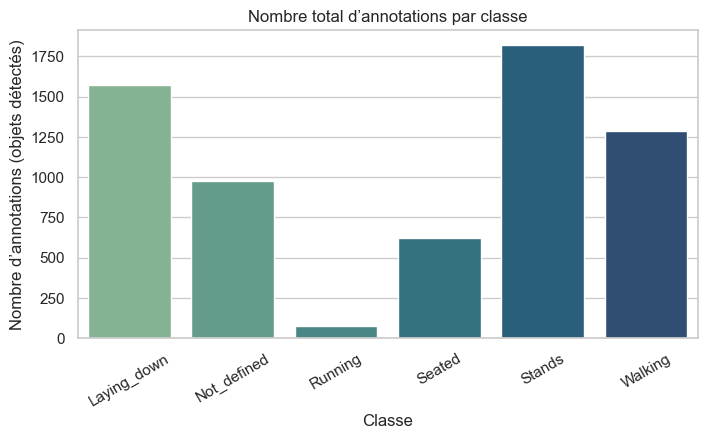

C:\Users\benwa\AppData\Local\Temp\ipykernel_18044\2040490640.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=images_per_class.index, y=images_per_class.values, palette="viridis")


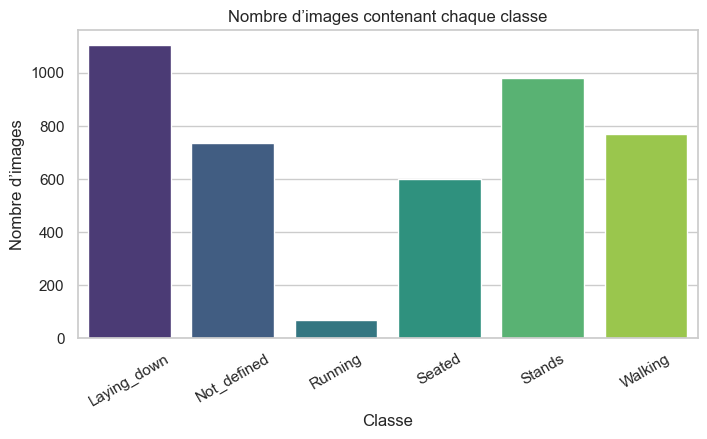

📦 Nombre moyen d’objets par image : 3.22
Image la plus chargée contient : 9 objets


In [33]:
# === 4. Analyse de la répartition des classes ===

# --- 4.1 Nombre d’annotations par classe ---
annotations_per_class = df["class_name"].value_counts().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(x=annotations_per_class.index, y=annotations_per_class.values, palette="crest")
plt.title("Nombre total d’annotations par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d’annotations (objets détectés)")
plt.xticks(rotation=30)
plt.show()

# --- 4.2 Nombre d’images contenant chaque classe ---
images_per_class = df.groupby("class_name")["file"].nunique().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(x=images_per_class.index, y=images_per_class.values, palette="viridis")
plt.title("Nombre d’images contenant chaque classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d’images")
plt.xticks(rotation=30)
plt.show()

# --- 4.3 Moyenne d’objets par image ---
objects_per_image = df.groupby("file").size()
print(f"📦 Nombre moyen d’objets par image : {objects_per_image.mean():.2f}")
print(f"Image la plus chargée contient : {objects_per_image.max()} objets")


In [34]:
# === 5. Statistiques descriptives ===
quant_vars = ["x_center", "y_center", "width", "height"]
print("=== Statistiques descriptives des variables quantitatives ===")
print(df[quant_vars].describe().T)


=== Statistiques descriptives des variables quantitatives ===
           count      mean       std       min       25%       50%       75%  \
x_center  6354.0  0.501729  0.241245  0.012240  0.305729  0.492969  0.688216   
y_center  6354.0  0.415600  0.240463  0.013889  0.212037  0.392593  0.571759   
width     6354.0  0.024552  0.018547  0.003646  0.012500  0.019271  0.030729   
height    6354.0  0.054299  0.030165  0.009259  0.033333  0.046296  0.065741   

               max  
x_center  0.996615  
y_center  0.988889  
width     0.183854  
height    0.312037  


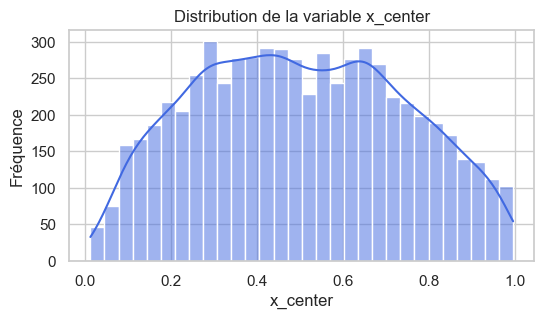

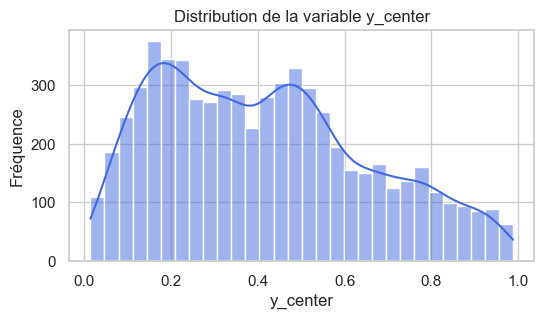

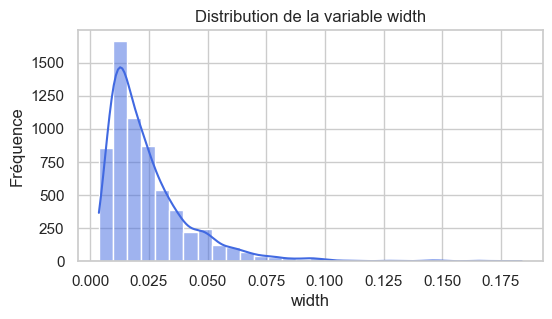

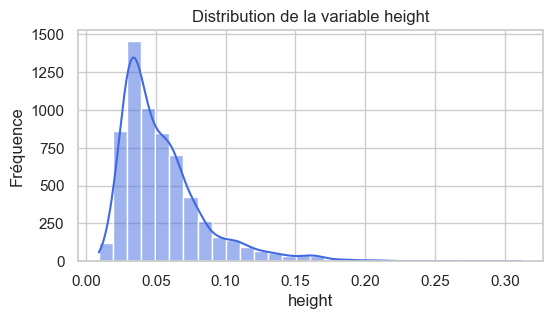

In [35]:
# === 6. Distribution des variables quantitatives ===
for var in quant_vars:
    plt.figure(figsize=(6,3))
    sns.histplot(df[var], kde=True, bins=30, color="royalblue")
    plt.title(f"Distribution de la variable {var}")
    plt.xlabel(var)
    plt.ylabel("Fréquence")
    plt.show()


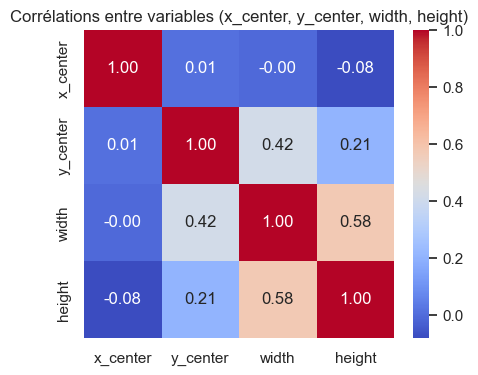

          x_center  y_center     width    height
x_center  1.000000  0.010653 -0.004375 -0.079775
y_center  0.010653  1.000000  0.416885  0.205746
width    -0.004375  0.416885  1.000000  0.575957
height   -0.079775  0.205746  0.575957  1.000000


In [36]:
# === 7. Corrélations entre variables ===
correlations = df[quant_vars].corr()
plt.figure(figsize=(5,4))
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations entre variables (x_center, y_center, width, height)")
plt.show()

print(correlations)
